# 01 - Data Preprocessing (shared by all four models)

**Problem:** predict whether a mortgage will be **fully prepaid within 24 months** of origination.
`1` = Prepayment, `0` = No prepayment.

**Data:** Freddie Mac Single-Family Loan-Level sample, 2019 originations (50,000 loans).
- *Origination file* - one row per loan, information known on the day the loan was made.
- *Performance file* - one row per loan per month, tells us what happened afterwards.

**Design rules (important for the viva):**
1. The **target** comes from the performance file. The **features** come only from the origination file.
   Performance columns (e.g. current balance) are only known *after* the outcome, so using them as features = data leakage.
2. The train/test split is done **before** fitting the imputer / encoder / scaler, which are fitted on **train only**.
3. The same saved split is used by Logistic Regression, SVM, GDA and the Neural Network.

In [1]:
import os, json, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 42          # same seed everywhere -> reproducible split
HORIZON = 24       # prepayment must happen within 24 months of loan age
RAW, PROC, PLOTS = "../data/raw", "../data/processed", "../results/plots"
os.makedirs(PROC, exist_ok=True)
os.makedirs(PLOTS, exist_ok=True)

## 1. Load the raw data
The raw files have **no header row**, so we name the columns by position (Freddie Mac standard layout, checked against the value ranges in the data).

In [2]:
# unzip once (the txt files are git-ignored because they are large)
if not os.path.exists(f"{RAW}/sample_orig_2019.txt"):
    with zipfile.ZipFile(f"{RAW}/sample_2019.zip") as z:
        z.extractall(RAW)

orig_cols = ["credit_score", "first_pay_date", "first_time_buyer", "maturity_date", "msa", "mi_pct",
             "units", "occupancy", "cltv", "dti", "upb", "ltv", "interest_rate", "channel", "ppm_flag",
             "amort_type", "state", "property_type", "zip3", "loan_id", "purpose", "term", "borrowers",
             "seller", "super_conforming", "pre_relief_id", "program", "relief_refi", "valuation",
             "io_flag", "mi_cancel"]
orig = pd.read_csv(f"{RAW}/sample_orig_2019.txt", sep="|", header=None, names=orig_cols)
print("Origination file:", orig.shape)
orig.head()

Origination file: (50000, 31)


/tmp/ipykernel_149/4059362606.py:11: DtypeWarning: Columns (0: pre_relief_id) have mixed types. Specify dtype option on import or set low_memory=False.
  orig = pd.read_csv(f"{RAW}/sample_orig_2019.txt", sep="|", header=None, names=orig_cols)


,credit_score,first_pay_date,first_time_buyer,maturity_date,msa,mi_pct,units,occupancy,cltv,dti,...,term,borrowers,seller,super_conforming,pre_relief_id,program,relief_refi,valuation,io_flag,mi_cancel
0,741,201903,N,204902,NaN,0,1,P,80,33,...,360,2,OTHER,N,NaN,NaN,N,7,N,9999
1,731,201903,N,204902,13460.0,0,1,P,77,44,...,360,1,OTHER,N,NaN,NaN,N,7,N,9999
2,722,201903,N,204902,NaN,30,1,P,95,41,...,360,2,OTHER,N,NaN,NaN,N,7,N,9999
3,729,201903,N,204902,NaN,25,1,P,87,17,...,360,1,OTHER,N,NaN,NaN,N,7,N,9999
4,773,201903,N,204902,33700.0,0,1,P,29,43,...,360,2,OTHER,N,NaN,NaN,N,7,N,9999


In [3]:
# The performance file has 35 columns and ~1.9 million rows. We only need 5 of them to build the target.
perf_cols = {0: "loan_id", 1: "month", 2: "current_upb", 4: "loan_age", 8: "zero_bal_code"}
perf = pd.read_csv(f"{RAW}/sample_perf_2019.txt", sep="|", header=None,
                   usecols=list(perf_cols), dtype={8: str}).rename(columns=perf_cols)
print("Performance file (needed columns only):", perf.shape)
print("Loans in performance file:", perf.loan_id.nunique())
perf.head()

Performance file (needed columns only): (1934614, 5)
Loans in performance file: 50000


,loan_id,month,current_upb,loan_age,zero_bal_code
0,F19Q10000056,201902,372000.0,0,NaN
1,F19Q10000056,201903,372000.0,1,NaN
2,F19Q10000056,201904,371000.0,2,NaN
3,F19Q10000056,201905,370000.0,3,NaN
4,F19Q10000056,201906,370000.0,4,NaN


**Zero Balance Code** is filled in only on the last row of a loan that has ended. `01` = prepaid in full.
Other codes (02 third-party sale, 03 short sale, 09 REO, 15/16 sales, 96 removal) are non-prepayment endings.

In [4]:
print(perf.zero_bal_code.value_counts(dropna=False))

zero_bal_code
NaN    1898860
01       35551
96         123
16          31
02          18
09          14
15          13
03           4
Name: count, dtype: int64


### Why we do NOT use `current_upb` (the reference paper's top feature)
The paper found `current_UPB` to be its most important feature. Let's check why.

In [5]:
prepaid_rows = perf[perf.zero_bal_code == "01"]
print("Max current_upb on prepayment rows:", prepaid_rows.current_upb.max())
print("Rows with UPB == 0 that are NOT a loan ending:",
      ((perf.current_upb == 0) & perf.zero_bal_code.isna()).sum())

Max current_upb on prepayment rows: 0.0
Rows with UPB == 0 that are NOT a loan ending: 0


Balance is **exactly 0 on every prepayment row** and never 0 otherwise. So `current_upb == 0` *is* the label. This is data leakage,
and it explains the paper's ~99.9 % accuracy. We use **origination-only features**, so our accuracy will be lower but honest.

## 2. Clean inconsistent loans
For some loan IDs the performance file contains two overlapping histories (the same loan age appears twice). We cannot tell which history is correct, so we remove those loans.

In [6]:
dup_age = perf.duplicated(["loan_id", "loan_age"], keep=False)
bad_ids = perf.loc[dup_age, "loan_id"].unique()
print("Loans with a repeated loan age (inconsistent history):", len(bad_ids))
perf = perf[~perf.loan_id.isin(bad_ids)]

Loans with a repeated loan age (inconsistent history): 889


## 3. Create the binary target
`target = 1` if the loan's zero-balance code is `01` **and** it happened at loan age <= 24 months. Everything else is `0`
(still active after 24 months, prepaid later, or ended for a non-prepayment reason).

A fixed 24-month window gives every loan the same observation period.
One more check: a loan with no ending record and fewer than 24 months of history would be unobservable, so we drop it.

In [7]:
ended = perf[perf.zero_bal_code.notna()][["loan_id", "loan_age", "zero_bal_code"]]

# loans that disappear before month 24 without any ending record -> outcome unknown -> drop
last_age = perf.groupby("loan_id").loan_age.max()
censored_ids = last_age[(last_age < HORIZON) & ~last_age.index.isin(ended.loan_id)].index
print("Loans with unknown outcome (dropped):", len(censored_ids))

prepaid_ids = ended[(ended.zero_bal_code == "01") & (ended.loan_age <= HORIZON)].loan_id

orig = orig[~orig.loan_id.isin(bad_ids) & ~orig.loan_id.isin(censored_ids)].copy()
orig["target"] = orig.loan_id.isin(prepaid_ids).astype(int)

print("Loans kept:", len(orig))
print(orig.target.value_counts())
print("Prepayment rate: %.3f" % orig.target.mean())

Loans with unknown outcome (dropped): 0
Loans kept: 49111
target
1    25749
0    23362
Name: count, dtype: int64
Prepayment rate: 0.524


The classes are almost balanced (about 52 % / 48 %), so no resampling or class weights are needed.

## 4. Understand and select features
**Features used (all known at origination):**

| Type | Columns |
|---|---|
| Numeric | `credit_score`, `dti` (debt-to-income), `ltv` (loan-to-value), `interest_rate`, `upb` (loan amount), `term`, `mi_pct` (mortgage insurance %), `units`, `borrowers` |
| Binary | `first_time_buyer` |
| Categorical | `occupancy`, `channel`, `property_type`, `purpose` |

**Deliberately left out:** all performance columns (leakage), `loan_id` (identifier), `cltv` (correlation with `ltv` is 0.995, it would only duplicate information),
`msa`/`zip3`/`state`/`seller` (too many categories for little gain), `first_pay_date`, and columns that are constant or almost empty.

In [8]:
num_cols = ["credit_score", "dti", "ltv", "interest_rate", "upb", "term", "mi_pct", "units", "borrowers"]
bin_cols = ["first_time_buyer"]
cat_cols = ["occupancy", "channel", "property_type", "purpose"]

print("corr(ltv, cltv) = %.3f  -> keep only ltv" % orig[["ltv", "cltv"]].corr().iloc[0, 1])

# Freddie Mac 'not available' codes -> missing
orig["credit_score"] = orig.credit_score.replace(9999, np.nan)
orig["dti"] = orig.dti.replace(999, np.nan)
orig["mi_pct"] = orig.mi_pct.replace(999, np.nan)
orig["units"] = orig.units.replace(99, np.nan)
orig["ltv"] = orig.ltv.replace(999, np.nan)
orig["borrowers"] = orig.borrowers.replace(99, np.nan)
orig["first_time_buyer"] = (orig.first_time_buyer == "Y").astype(int)

data = orig[num_cols + bin_cols + cat_cols + ["target"]]
print("Missing values per column:")
print(data.isna().sum()[data.isna().sum() > 0])
data.describe().T[["min", "mean", "max"]]

corr(ltv, cltv) = 0.966  -> keep only ltv
Missing values per column:
credit_score    18
dti             29
dtype: int64


,min,mean,max
credit_score,562.00,749.738130,832.00
dti,1.00,35.283526,50.00
ltv,5.00,75.617519,103.00
interest_rate,2.35,4.235909,6.75
upb,15000.00,254992.506770,1397000.00
term,96.00,331.901590,360.00
mi_pct,0.00,7.946855,35.00
units,1.00,1.029199,4.00
borrowers,1.00,1.474110,5.00
first_time_buyer,0.00,0.224003,1.00


                mean   size
interest_rate              
(0.0, 3.25]    0.402   1871
(3.25, 3.75]   0.484   9294
(3.75, 4.25]   0.545  16920
(4.25, 4.75]   0.569  12827
(4.75, 5.25]   0.496   5765
(5.25, 10.0]   0.456   2434


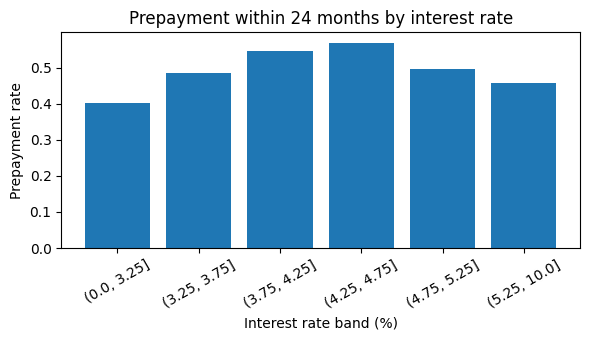

In [9]:
# Quick look: prepayment rate by interest-rate band.
# It rises then falls, i.e. the relationship is NOT linear (a reason a neural network might help).
bands = pd.cut(data.interest_rate, [0, 3.25, 3.75, 4.25, 4.75, 5.25, 10])
rate_table = data.groupby(bands, observed=True).target.agg(["mean", "size"])
print(rate_table.round(3))

plt.figure(figsize=(6, 3.5))
plt.bar(rate_table.index.astype(str), rate_table["mean"])
plt.ylabel("Prepayment rate"); plt.xlabel("Interest rate band (%)")
plt.title("Prepayment within 24 months by interest rate")
plt.xticks(rotation=30); plt.tight_layout()
plt.savefig(f"{PLOTS}/preprocessing_prepay_by_rate.png", dpi=150)
plt.show()

## 5. Train / test split (BEFORE any fitting)
80 % train / 20 % test, stratified so both sets keep the same class ratio. `random_state=42`.
The test set is not looked at again until final evaluation.

In [10]:
X = data.drop(columns="target")
y = data["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Prepayment rate  train: %.3f   test: %.3f" % (y_train.mean(), y_test.mean()))

Train: (39288, 14)  Test: (9823, 14)
Prepayment rate  train: 0.524   test: 0.524


## 6. Missing values -> median (fitted on TRAIN only)
Only a few dozen values are missing, so this barely matters, but the medians must come from the training set to avoid leakage.

In [11]:
medians = X_train[num_cols].median()          # learned from train only
X_train = X_train.copy(); X_test = X_test.copy()
X_train[num_cols] = X_train[num_cols].fillna(medians)
X_test[num_cols] = X_test[num_cols].fillna(medians)   # test uses TRAIN medians
print("Missing after imputation:", X_train.isna().sum().sum(), X_test.isna().sum().sum())

Missing after imputation: 0 0


## 7. Categorical variables -> one-hot encoding
Each category becomes a 0/1 column. `drop_first=True` drops one column per variable (it is implied by the others),
which avoids perfectly redundant columns - useful for Logistic Regression and necessary for GDA's covariance matrix.
The columns are defined by the train set and the test set is aligned to them.

In [12]:
X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True, dtype=int)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True, dtype=int)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)   # same columns, same order
print("Features after encoding:", X_train.shape[1])
print(list(X_train.columns))

Features after encoding: 20
['credit_score', 'dti', 'ltv', 'interest_rate', 'upb', 'term', 'mi_pct', 'units', 'borrowers', 'first_time_buyer', 'occupancy_P', 'occupancy_S', 'channel_C', 'channel_R', 'property_type_CP', 'property_type_MH', 'property_type_PU', 'property_type_SF', 'purpose_N', 'purpose_P']


## 8. Scale numeric features (fitted on TRAIN only)
`StandardScaler` -> mean 0, std 1. This matters for Logistic Regression (regularisation), SVM and the Neural Network, which are sensitive to feature scale.
The 0/1 columns (`first_time_buyer` and the one-hot columns) are left as they are.

In [13]:
scaler = StandardScaler().fit(X_train[num_cols])       # mean/std learned from train only
X_train[num_cols] = scaler.transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])
print(X_train[num_cols].mean().round(3).to_dict())
print(X_test[num_cols].mean().round(3).to_dict(), "<- not exactly 0 for test, as expected")

{'credit_score': 0.0, 'dti': 0.0, 'ltv': 0.0, 'interest_rate': -0.0, 'upb': 0.0, 'term': 0.0, 'mi_pct': 0.0, 'units': 0.0, 'borrowers': -0.0}
{'credit_score': 0.011, 'dti': -0.026, 'ltv': 0.004, 'interest_rate': -0.018, 'upb': 0.0, 'term': -0.004, 'mi_pct': 0.002, 'units': 0.001, 'borrowers': 0.008} <- not exactly 0 for test, as expected


## 9. Final checks and save

In [14]:
assert list(X_train.columns) == list(X_test.columns)
assert X_train.isna().sum().sum() == 0 and X_test.isna().sum().sum() == 0
assert len(X_train) == len(y_train) and len(X_test) == len(y_test)

X_train.to_csv(f"{PROC}/X_train.csv", index=False)
X_test.to_csv(f"{PROC}/X_test.csv", index=False)
y_train.to_frame("target").to_csv(f"{PROC}/y_train.csv", index=False)
y_test.to_frame("target").to_csv(f"{PROC}/y_test.csv", index=False)

summary = {
    "target": "1 = loan prepaid in full (zero balance code 01) at loan age <= 24 months, else 0",
    "split": "80/20 stratified", "seed": SEED,
    "n_loans_kept": int(len(data)), "n_removed_inconsistent": int(len(bad_ids)),
    "n_removed_unknown_outcome": int(len(censored_ids)),
    "n_train": int(len(X_train)), "n_test": int(len(X_test)), "n_features": int(X_train.shape[1]),
    "prepay_rate_train": round(float(y_train.mean()), 4), "prepay_rate_test": round(float(y_test.mean()), 4),
    "baseline_majority_accuracy_test": round(float(max(y_test.mean(), 1 - y_test.mean())), 4),
    "numeric_scaled_columns": num_cols,
    "binary_columns": bin_cols,
    "onehot_columns": [c for c in X_train.columns if c not in num_cols + bin_cols],
    "feature_order": list(X_train.columns),
    "missing_value_handling": "Freddie Mac codes (9999/999/99) -> NaN -> median of train",
    "excluded": "all performance-file columns (leakage), loan_id, cltv, msa, zip3, state, seller, first_pay_date, constant columns",
}
with open(f"{PROC}/preprocessing_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print(json.dumps({k: summary[k] for k in ["n_train", "n_test", "n_features", "prepay_rate_train", "prepay_rate_test", "baseline_majority_accuracy_test"]}, indent=2))

{
  "n_train": 39288,
  "n_test": 9823,
  "n_features": 20,
  "prepay_rate_train": 0.5243,
  "prepay_rate_test": 0.5243,
  "baseline_majority_accuracy_test": 0.5243
}


**Saved to `data/processed/`:** `X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv`, `preprocessing_summary.json`.
Every model notebook loads exactly these files, so all four models see the same data and the same test set.